# Student Information

**Name:** Liam Johnie
**Student Number:** ST10536072
**Module:** PDAN8411 POE Part 1

# Medical Cost Analysis - Part 1: Linear Regression

**Subtitle:** Proof-of-concept linear regression model for a South African medical aid scheme, trained on a US health insurance dataset.

## 1. Dataset Suitability for Linear Regression

### 1.1 What Linear Regression Requires

Linear regression predicts a continuous, numeric outcome by fitting a straight-line relationship between a target variable and one or more predictor variables (scikit-learn developers, 2024a). The algorithm rests on four core statistical assumptions: **Linearity** - each predictor has an approximately linear relationship with the target; **Independence** - observations are independent of one another; **Homoscedasticity** - the residuals (differences between predicted and actual values) have roughly constant spread across all fitted values; and **Normality of residuals** - the residuals follow an approximately normal distribution (GeeksforGeeks, 2024). Categorical predictor variables stored as text must first be converted into numeric form through a process called encoding before they can be passed to the model. Finally, predictors should not be too strongly correlated with each other - a problem known as multicollinearity - because high overlap between predictors makes it difficult to isolate the individual effect of each one (GeeksforGeeks, 2024).

### 1.2 Why This Dataset Fits

The dataset was originally published on Kaggle and contains 1,338 rows, which is adequate for a proof-of-concept regression model (Choi, 2018). The target variable, `charges`, is a continuous, numeric value measured in US dollars, directly satisfying the core requirement that linear regression needs a numeric outcome to predict (Choi, 2018). The seven columns provide a realistic mix of numeric predictors - `age`, `bmi`, and `children` - and categorical predictors - `sex`, `smoker`, and `region` - which will be encoded into numeric form before modelling (Choi, 2018).

### 1.3 Data Quality Pitfalls to Check During EDA

The following potential issues will be inspected during the Exploratory Data Analysis (EDA) phase before any modelling takes place:

- **Missing values** - any `NaN` entries must be identified and handled before the data can be passed to a model.
- **Duplicate rows** - exact duplicate records can distort coefficient estimates and will be identified and removed.
- **Outliers in `bmi` and `charges`** - extreme values can have a disproportionate influence on the least-squares fit.
- **Skewness of `charges`** - because smokers tend to incur substantially higher costs, `charges` is likely right-skewed; a log transformation may be required.
- **Multicollinearity between predictors** - predictors that are strongly correlated with each other will first be inspected visually using a correlation heatmap in EDA, then quantified using the Variance Inflation Factor (VIF) during Feature Selection.
- **Correct encoding of categorical variables** - `sex`, `smoker`, and `region` must be converted to numeric dummy variables before being passed to the model.

Linearity and multicollinearity will be inspected before the model is fitted, using scatter plots and a correlation heatmap during EDA. Homoscedasticity and normality of residuals can only be checked after the model is fitted, and will be verified using a residuals-vs-fitted plot and a QQ plot of residuals during Model Evaluation.

## 2. Analysis Plan

### 2.1 EDA Plan

- Check the shape of the dataset (number of rows and columns) and the data type of each column.
- Check for missing values in every column.
- Check for and remove any duplicate rows.
- Use `describe()` to obtain summary statistics for all numeric columns (count, mean, standard deviation, minimum, quartiles, maximum).
- Use `value_counts()` for each categorical column (`sex`, `smoker`, `region`) to understand category distributions.
- Plot histograms for all numeric columns (`age`, `bmi`, `children`, `charges`) to inspect distributions and detect skewness.
- Plot boxplots for numeric columns to surface outliers visually.
- Plot countplots for categorical columns to visualise category frequencies.
- Plot a correlation heatmap for all numeric features to identify linear relationships and potential multicollinearity.
- Plot scatter plots of `age` and `bmi` against `charges` to assess linearity visually. For `bmi` vs `charges`, colour points by smoker status to reveal the expected interaction effect.
- Plot a grouped boxplot of `charges` by number of `children`, since `children` is a discrete integer count (0 to 5) and a scatter plot would only show vertical stripes. A scatter is also shown for completeness.
- Plot grouped boxplots of `charges` split by each categorical feature (`sex`, `smoker`, `region`) to reveal group-level effects on cost.

### 2.2 Feature Selection Plan

The three categorical columns (`sex`, `smoker`, and `region`) will first be one-hot encoded to convert them into numeric dummy variables suitable for linear regression. Pearson correlation coefficients will then be calculated between each numeric feature and `charges` to identify the strongest individual linear predictors. A statsmodels Ordinary Least Squares (OLS) model will be fitted on all candidate features to obtain coefficient p-values; any feature with a p-value greater than 0.05 will be dropped one at a time using backward elimination, repeating until only statistically significant predictors remain (statsmodels developers, 2024a). The Variance Inflation Factor (VIF) will then be calculated for each remaining predictor to detect multicollinearity, with a VIF greater than 5 used as the threshold for concern (statsmodels developers, 2024b).

### 2.3 Model Training Plan

The processed dataset will be split into training (80%) and test (20%) subsets using scikit-learn's `train_test_split` function with `random_state=42` to ensure the split is identical across different runs of the notebook (scikit-learn developers, 2024b). The model will be a scikit-learn `LinearRegression` estimator with default settings; note that ordinary least-squares linear regression has no traditional tuning hyperparameters - only options such as `fit_intercept` - so no cross-validated grid search is required (scikit-learn developers, 2024a). The model will be fitted exclusively on the training set and used to generate predictions on the held-out test set to obtain an unbiased estimate of generalisation performance. If residual diagnostics reveal that `charges` is severely right-skewed, a log transformation of `charges` will be applied and the model retrained on the transformed target.

### 2.4 Evaluation Plan

The following metrics and diagnostic plots will be produced on both the training set and the test set; training and test scores will be compared to detect overfitting (a high training score paired with a substantially lower test score indicates the model has not generalised well):

- **R-squared (R²):** proportion of variance in `charges` explained by the model; a value closer to 1 indicates a better fit (scikit-learn developers, 2024c).
- **Adjusted R-squared:** R² penalised for the number of predictors included, making it more useful when comparing the full model with the feature-selected model (scikit-learn developers, 2024c).
- **RMSE (Root Mean Squared Error):** the square root of the average squared prediction error, expressed in the same units as `charges` (USD) and therefore directly interpretable as an average dollar error (scikit-learn developers, 2024c).
- **MAE (Mean Absolute Error):** the average absolute prediction error; less sensitive than RMSE to large individual errors caused by outliers (scikit-learn developers, 2024c).
- **Residual plot (residuals vs fitted values):** a scatter plot used to check visually whether the homoscedasticity and linearity assumptions hold - a well-behaved model shows residuals scattered randomly around zero with no funnel shape or curve.
- **QQ plot of residuals:** a quantile-quantile plot comparing the distribution of residuals to a theoretical normal distribution; points close to the diagonal line indicate that the normality-of-residuals assumption is satisfied.

### 2.5 Report Plan

After the notebook is complete, a PDF report will be written covering the following sections: Summary Overview, Introduction, Dataset Overview, Exploratory Data Analysis, Data Splitting, Model Creation and Fitting, Model Evaluation, Conclusion, and References. Each section will draw directly on the outputs, charts, and metrics produced in this notebook, with figures reproduced and interpreted in the report. Harvard Anglia referencing style, as specified by The IIE, will be applied consistently throughout.

## 3. Libraries

We import all the libraries needed for the analysis upfront so that dependencies are visible in one place and any missing packages are caught immediately when the notebook is opened. A fixed random seed (`RANDOM_STATE = 42`) is defined here and passed to any function that involves randomness - such as the train/test split - so that every run of the notebook produces identical results. This includes statsmodels (statsmodels developers, 2024a) for OLS regression and VIF calculation in Step 3, and scikit-learn (scikit-learn developers, 2024a) for the regression model, data splitting, and evaluation metrics in Step 4. scipy.stats (SciPy developers, 2024) is used for the QQ plot of residuals.

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import scipy.stats as stats

RANDOM_STATE = 42

## 4. Exploratory Data Analysis

This section follows the EDA plan in section 2.1. Steps 4.1 to 4.6 check the dataset's structure and data quality. Steps 4.7 to 4.13 use charts to understand distributions, outliers, category frequencies, and relationships between variables. Step 4.14 summarises the key findings that will guide Step 3 (Feature Selection) and the modelling decisions in Step 4.

### 4.1 Load the Dataset

We load the insurance CSV file into a pandas DataFrame using `pd.read_csv` and print the row and column count to confirm the file loaded correctly (pandas development team, 2024).

In [72]:
df = pd.read_csv('insurance_data/insurance.csv')
print('Rows:', df.shape[0], ' | Columns:', df.shape[1])

Rows: 1338  | Columns: 7


### 4.2 Shape, Data Types, and First Rows

We check the shape, data types, and first five rows to confirm all seven columns loaded with the expected types (pandas development team, 2024).

In [73]:
print('Shape:', df.shape)
print()
print(df.dtypes)
print()
df.head()

Shape: (1338, 7)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset has 1,338 rows and 7 columns at this stage. The data types match expectations: `age` and `children` are integers, `bmi` and `charges` are floating-point numbers, and `sex`, `smoker`, and `region` are string objects that will need one-hot encoding before being passed to the model. No unexpected columns or loading errors were detected.

### 4.3 Missing Value Check

We call `df.isnull().sum()` to count any `NaN` entries in every column (pandas development team, 2024).

In [74]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

All seven columns return a count of zero, confirming there are no missing values in the dataset. No imputation or row removal is needed for this reason, and all 1,338 rows are retained at this stage.

### 4.4 Duplicate Row Check and Removal

We use `df.duplicated().sum()` to count exact duplicate rows and `df.drop_duplicates()` to remove them if any are found (pandas development team, 2024).

In [75]:
rows_before = len(df)
dups = df.duplicated().sum()
print('Duplicate rows found:', dups)

if dups > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Rows before removal:', rows_before)
    print('Rows after removal: ', len(df))
else:
    print('No duplicates found. Row count unchanged:', rows_before)

Duplicate rows found: 1
Rows before removal: 1338
Rows after removal:  1337


One duplicate row was found and removed, reducing the dataset from 1,338 to 1,337 rows. All subsequent analysis uses this deduplicated `df`. The reduction is a super tiny percentage of the data and will not materially affect any statistic.

### 4.5 Summary Statistics

`df.describe()` returns count, mean, standard deviation, minimum, three quartiles, and maximum for every numeric column (pandas development team, 2024).

In [76]:
df.describe().round(2)

,age,bmi,children,charges
count,1337.00,1337.00,1337.00,1337.00
mean,39.22,30.66,1.10,13279.12
std,14.04,6.10,1.21,12110.36
min,18.00,15.96,0.00,1121.87
25%,27.00,26.29,0.00,4746.34
50%,39.00,30.40,1.00,9386.16
75%,51.00,34.70,2.00,16657.72
max,64.00,53.13,5.00,63770.43


The mean annual charge is $13,279.12 with a large standard deviation of $12,110.36, already indicating high spread and suggesting the distribution is likely right-skewed (a long tail of high values). `age` ranges from 18 to 64 with a mean of 39.22. `bmi` has a mean of 30.66, just above the clinical overweight threshold of 30, and reaches a maximum of 53.13. `children` has a median of 1 and a maximum of 5, indicating most policyholders have few or no dependants.

### 4.6 Categorical Column Value Counts

We call `value_counts()` on each categorical column to count how many observations fall into each category (pandas development team, 2024).

In [77]:
for col in ['sex', 'smoker', 'region']:
    print(f'--- {col} ---')
    print(df[col].value_counts())
    print()

--- sex ---
sex
male      675
female    662
Name: count, dtype: int64

--- smoker ---
smoker
no     1063
yes     274
Name: count, dtype: int64

--- region ---
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64



`sex` is nearly balanced (male: 675, female: 662). `smoker` is imbalanced: 1,063 non-smokers (79.5%) versus 274 smokers (20.5%). The four `region` categories are fairly balanced (southeast: 364, southwest: 325, northwest: 324, northeast: 324). No category is rare enough to produce a near-zero-variance dummy; the smoker imbalance is expected and will not cause modelling problems with 274 observations in the minority class.

### 4.7 Histograms of Numeric Variables

We plot histograms for all four numeric columns and print the skewness of `charges`, since section 1.3 flagged it as likely right-skewed (Waskom, 2021).

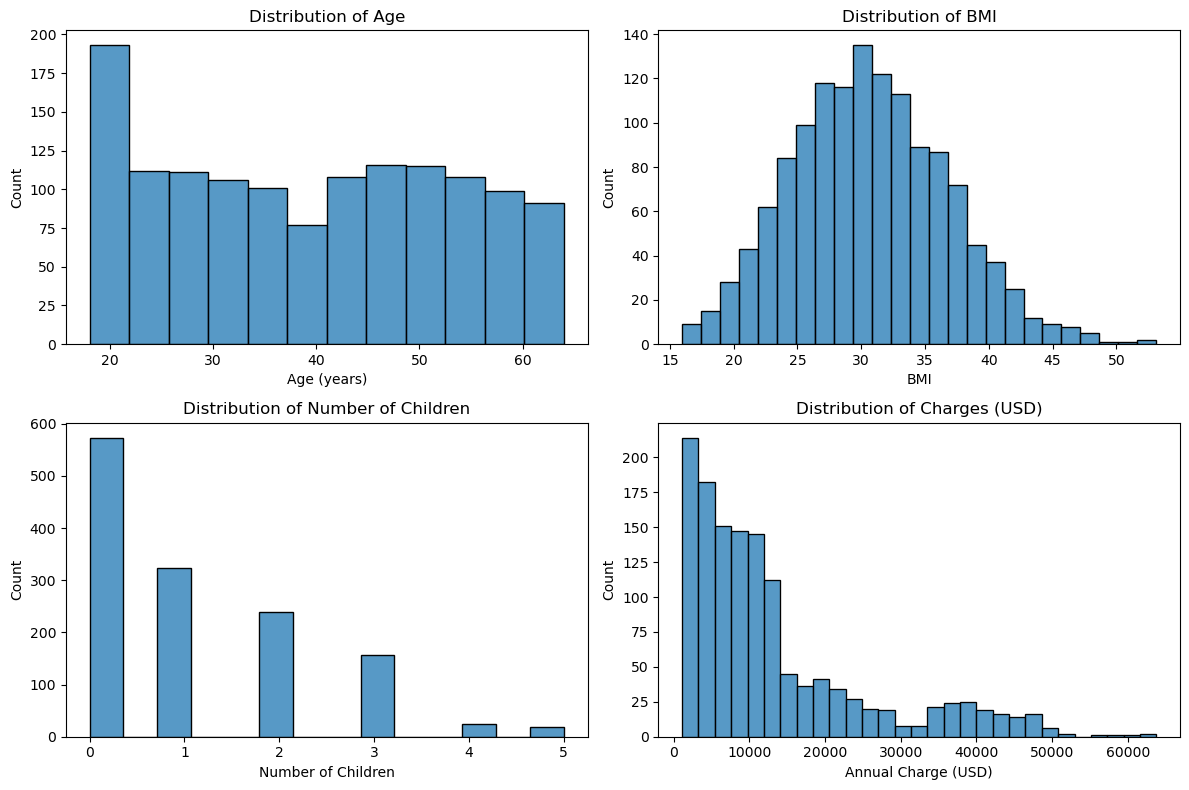

Skewness of charges: 1.5154

Children counts:
children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


In [78]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df['age'], ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Age')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Count')

sns.histplot(df['bmi'], ax=axes[0, 1])
axes[0, 1].set_title('Distribution of BMI')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Count')

sns.histplot(df['children'], ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Number of Children')
axes[1, 0].set_xlabel('Number of Children')
axes[1, 0].set_ylabel('Count')

sns.histplot(df['charges'], ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Charges (USD)')
axes[1, 1].set_xlabel('Annual Charge (USD)')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Skewness of charges:', round(df['charges'].skew(), 4))
print()
print('Children counts:')
print(df['children'].value_counts().sort_index())

`age` is approximately uniformly distributed across 18 to 64. `bmi` is roughly bell-shaped around a mean of 30.66. `children` is heavily right-skewed with 573 policyholders (42.8%) having no children. `charges` has a skewness of 1.5154, indicating a moderately right-skewed distribution with a long tail of high-cost claims; this is consistent with a smoker subgroup driving extreme values and warrants consideration of a log transformation before modelling, as noted in section 2.3.

### 4.8 Boxplots of Numeric Variables

We plot boxplots for all four numeric columns to visualise the spread and identify any outlier points beyond 1.5 times the IQR (Waskom, 2021).

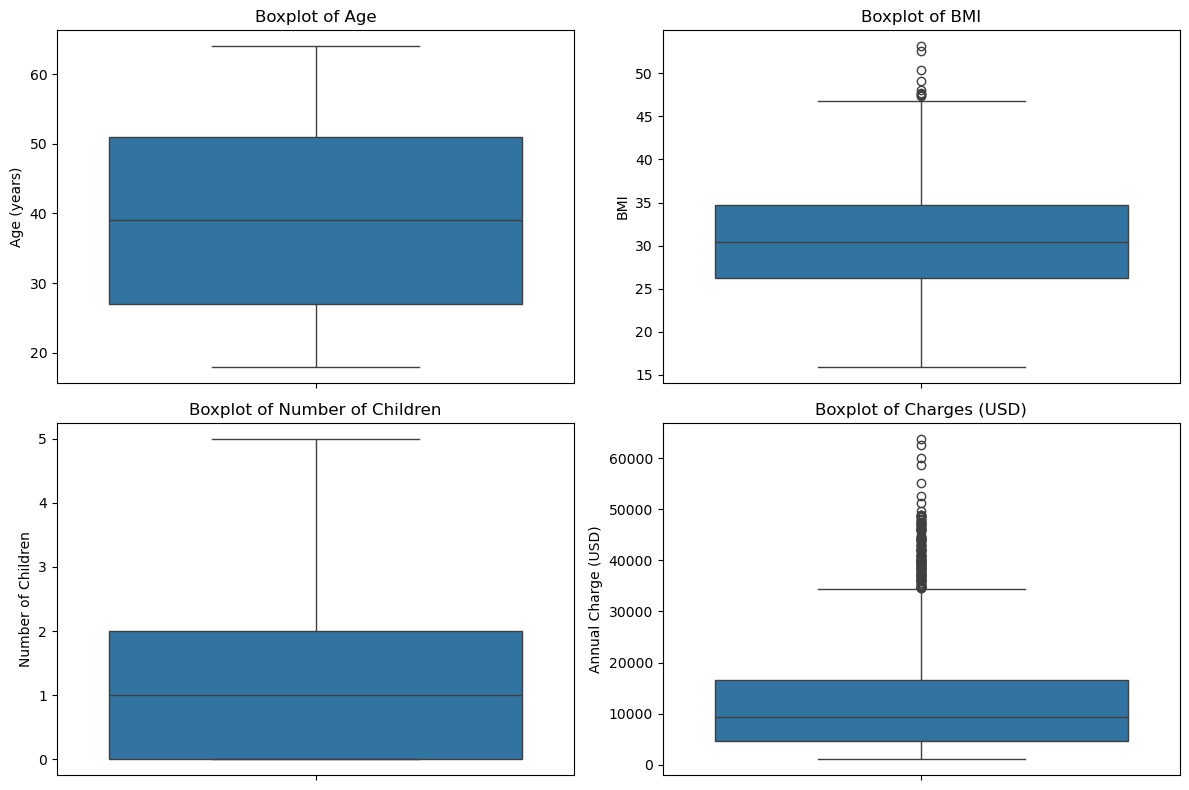

age upper fence: 87.0
age upper outliers: 0

bmi upper fence: 47.32
bmi upper outliers: 9
bmi max value: 53.13

charges upper fence: 34524.78
charges upper outliers: 139
charges max value: 63770.43



In [79]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.boxplot(data=df, y='age', ax=axes[0, 0])
axes[0, 0].set_title('Boxplot of Age')
axes[0, 0].set_ylabel('Age (years)')
axes[0, 0].set_xlabel('')

sns.boxplot(data=df, y='bmi', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of BMI')
axes[0, 1].set_ylabel('BMI')
axes[0, 1].set_xlabel('')

sns.boxplot(data=df, y='children', ax=axes[1, 0])
axes[1, 0].set_title('Boxplot of Number of Children')
axes[1, 0].set_ylabel('Number of Children')
axes[1, 0].set_xlabel('')

sns.boxplot(data=df, y='charges', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot of Charges (USD)')
axes[1, 1].set_ylabel('Annual Charge (USD)')
axes[1, 1].set_xlabel('')

plt.tight_layout()
plt.show()

for col in ['age', 'bmi', 'charges']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    upper_fence = q3 + 1.5 * iqr
    upper_outliers = df[df[col] > upper_fence]
    print(col, 'upper fence:', round(upper_fence, 2))
    print(col, 'upper outliers:', len(upper_outliers))
    if len(upper_outliers) > 0:
        print(col, 'max value:', round(df[col].max(), 2))
    print()

`age` has no outliers. `bmi` has 9 data points above its upper fence of 47.32, reaching a maximum of 53.13; these are unusual but plausible values and are retained in the dataset. `charges` has 139 points above its upper fence of $34,525, with a maximum of $63,770.43; this large count of upper outliers is consistent with the skewness of 1.5154 observed in step 4.7 and explains why both Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE) are included in the evaluation plan; RMSE is more sensitive to these extreme values than MAE.

### 4.9 Countplots of Categorical Variables

We plot a countplot for each categorical column to show the number of observations per category (Waskom, 2021).

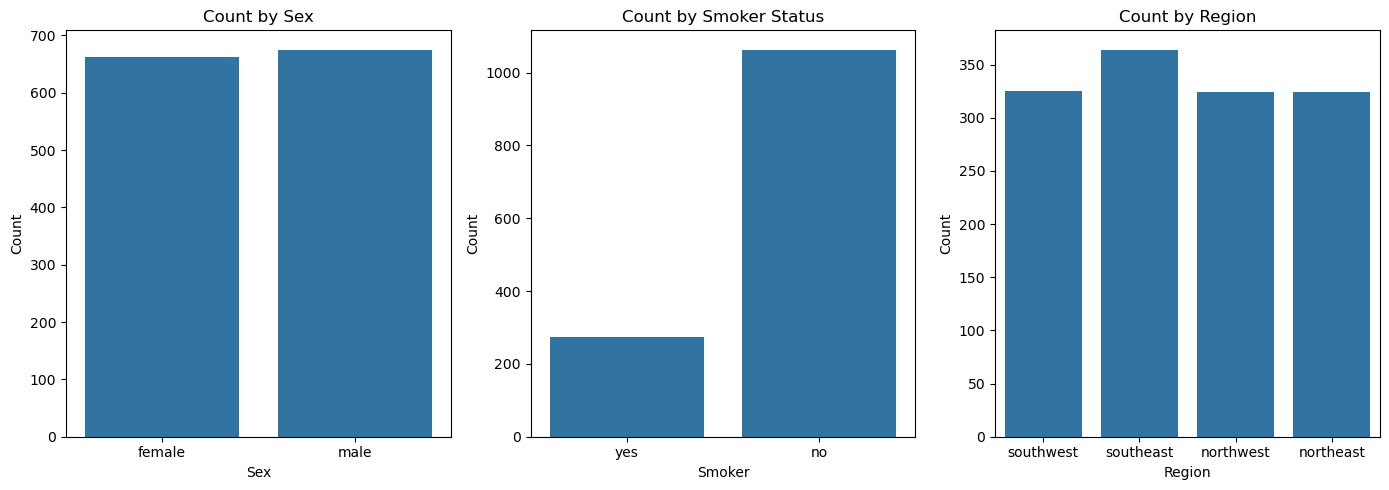

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.countplot(data=df, x='sex', ax=axes[0])
axes[0].set_title('Count by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=df, x='smoker', ax=axes[1])
axes[1].set_title('Count by Smoker Status')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Count')

sns.countplot(data=df, x='region', ax=axes[2])
axes[2].set_title('Count by Region')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

`sex` is nearly balanced (675 male, 662 female) so the `sex_male` dummy will have adequate variance after encoding. The smoker imbalance is clearly visible (1,063 non-smokers vs 274 smokers), yet 274 observations in the minority class is sufficient for the model to estimate a coefficient reliably. The four regions are roughly equal in size, with the southeast slightly larger (364 vs approximately 324 for the other three).

### 4.10 Correlation Heatmap

We create a temporary one-hot-encoded copy of `df` using `pd.get_dummies` and plot a Pearson correlation heatmap to identify which features are most linearly related to `charges` (Waskom, 2021).

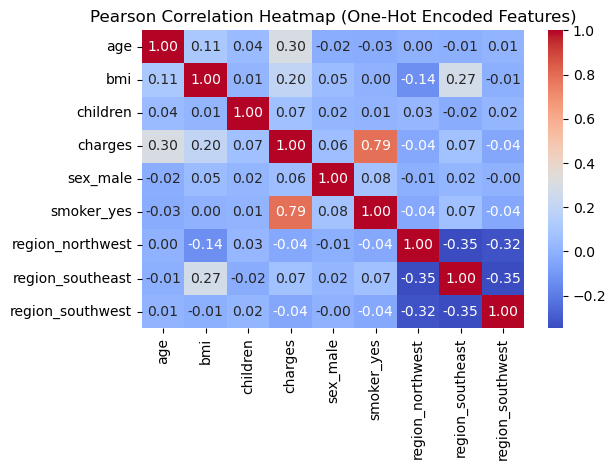

In [81]:
df_heatmap = pd.get_dummies(df, drop_first=True)

sns.heatmap(
    df_heatmap.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.title('Pearson Correlation Heatmap (One-Hot Encoded Features)')
plt.tight_layout()
plt.show()

`smoker_yes` has the highest correlation with `charges` at 0.79, confirming it is the dominant predictor. `age` (0.30) and `bmi` (0.20) are the next strongest. Among the predictors themselves, the highest pairwise correlation involving original features is `bmi` with `region_southeast` at 0.27, which is not concerning. The region dummies show expected mutual negative correlations of around -0.35 because they are parts of a one-hot-encoded set. Overall, multicollinearity between predictors appears low and will be confirmed with VIF in Step 3. The `region_northeast` dummy is absent by design: `drop_first=True` drops the first category to avoid the dummy variable trap, making northeast the reference level.

### 4.11 Scatter Plots: Age and BMI vs Charges

We plot `age` vs `charges` and `bmi` vs `charges` as scatter plots, colouring the `bmi` plot by `smoker` status to reveal the expected interaction effect (Waskom, 2021).

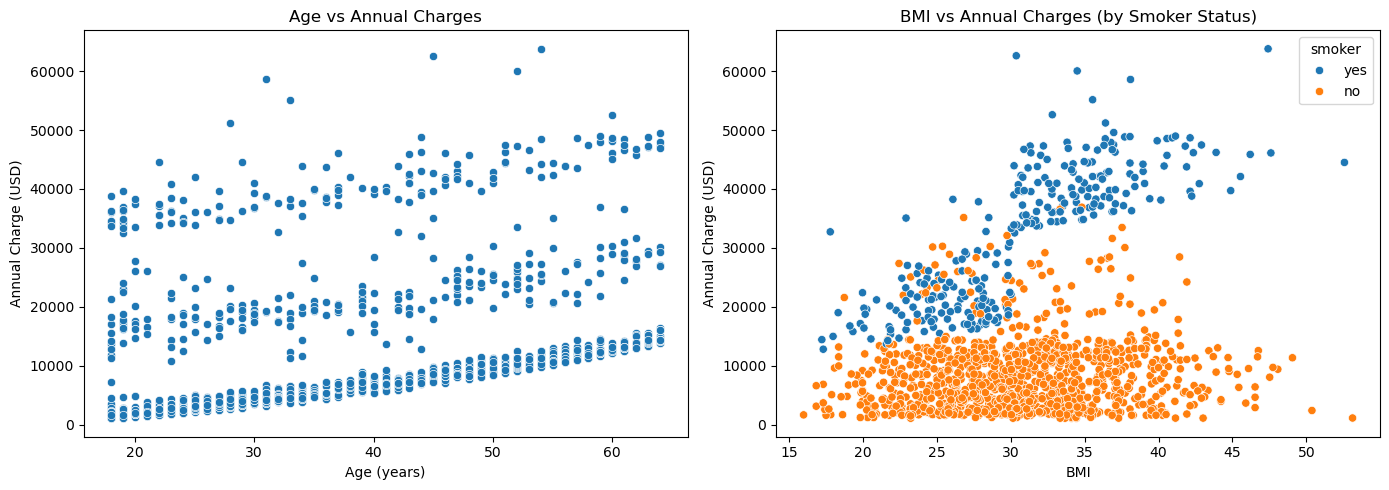

Median charges by smoker status:
smoker
no      7345.73
yes    34456.35
Name: charges, dtype: float64


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='age', y='charges', ax=axes[0])
axes[0].set_title('Age vs Annual Charges')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Annual Charge (USD)')

sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', ax=axes[1])
axes[1].set_title('BMI vs Annual Charges (by Smoker Status)')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Annual Charge (USD)')

plt.tight_layout()
plt.show()

print('Median charges by smoker status:')
print(df.groupby('smoker')['charges'].median().round(2))

The `age` vs `charges` scatter shows three roughly horizontal bands rather than a single line, suggesting that age has a positive relationship with charges within each band but that another variable, most likely smoker status, is splitting the data into groups. The `bmi` vs `charges` scatter confirms this: non-smokers cluster at low charges (median $7,346) regardless of BMI, while smokers above roughly BMI 30 form a distinct high-charge group (median $34,456 for all smokers). Because the relationship between `bmi` and `charges` differs for smokers and non-smokers, a simple linear model may not fully capture it, and the skewness of 1.5154 in `charges` supports considering a log transformation as noted in section 2.3.

### 4.12 Children vs Charges: Scatter and Grouped Boxplot

We show both a scatter plot and a grouped boxplot of `charges` by `children` count, since `children` is a discrete integer (0 to 5) and a scatter alone would only show vertical columns (Waskom, 2021).

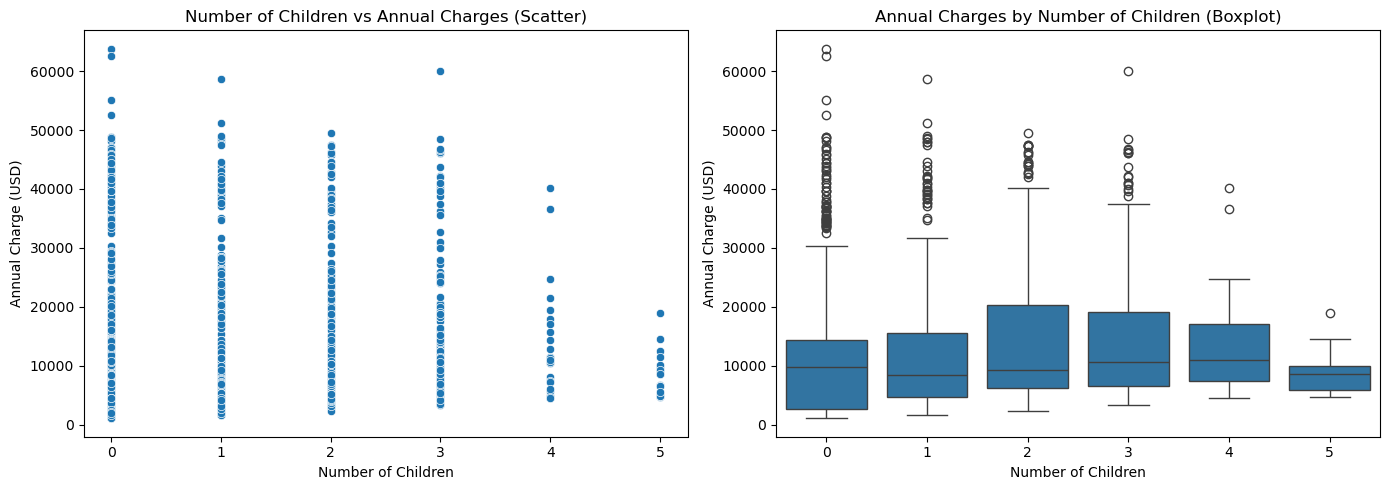

Median charges by number of children:
children
0     9863.47
1     8483.87
2     9264.98
3    10600.55
4    11033.66
5     8589.57
Name: charges, dtype: float64

Counts by number of children:
children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x='children', y='charges', ax=axes[0])
axes[0].set_title('Number of Children vs Annual Charges (Scatter)')
axes[0].set_xlabel('Number of Children')
axes[0].set_ylabel('Annual Charge (USD)')

sns.boxplot(data=df, x='children', y='charges', ax=axes[1])
axes[1].set_title('Annual Charges by Number of Children (Boxplot)')
axes[1].set_xlabel('Number of Children')
axes[1].set_ylabel('Annual Charge (USD)')

plt.tight_layout()
plt.show()

print('Median charges by number of children:')
print(df.groupby('children')['charges'].median().round(2))
print()
print('Counts by number of children:')
print(df['children'].value_counts().sort_index())

The scatter plot confirms six discrete vertical columns, making it unsuitable for assessing linearity. The grouped boxplot shows that median charges range only from $8,484 (1 child) to $11,034 (4 children) across groups - a spread of $2,550 - with no consistent increasing trend. The 4-children and 5-children groups have very few observations (25 and 18 respectively), making their medians unreliable. This is consistent with the weak Pearson correlation of 0.07 from the heatmap and confirms that `children` is a minor predictor of `charges`.

### 4.13 Charges Grouped by Categorical Features

We plot grouped boxplots of `charges` split by each categorical feature to see which categories are associated with higher or lower charges (Waskom, 2021).

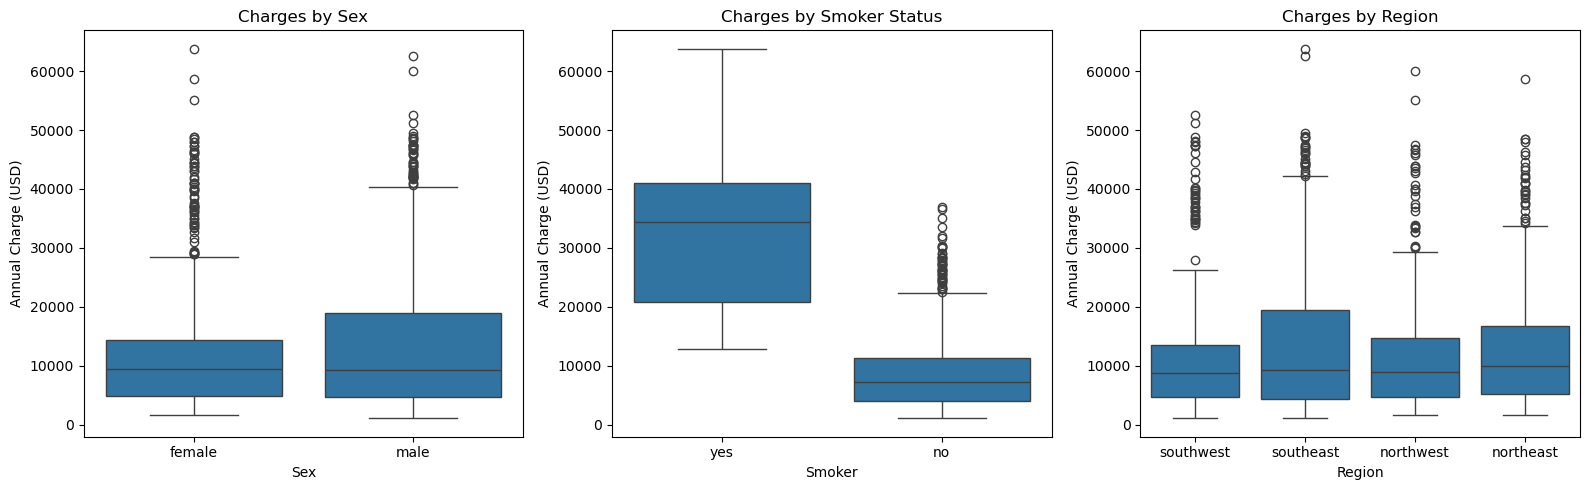

Median charges by sex:
sex
female    9412.96
male      9377.90
Name: charges, dtype: float64

Median charges by smoker status:
smoker
no      7345.73
yes    34456.35
Name: charges, dtype: float64

Median charges by region:
region
northeast    10057.65
northwest     8976.98
southeast     9294.13
southwest     8798.59
Name: charges, dtype: float64


In [84]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df, x='sex', y='charges', ax=axes[0])
axes[0].set_title('Charges by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Annual Charge (USD)')

sns.boxplot(data=df, x='smoker', y='charges', ax=axes[1])
axes[1].set_title('Charges by Smoker Status')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Annual Charge (USD)')

sns.boxplot(data=df, x='region', y='charges', ax=axes[2])
axes[2].set_title('Charges by Region')
axes[2].set_xlabel('Region')
axes[2].set_ylabel('Annual Charge (USD)')

plt.tight_layout()
plt.show()

print('Median charges by sex:')
print(df.groupby('sex')['charges'].median().round(2))
print()
print('Median charges by smoker status:')
print(df.groupby('smoker')['charges'].median().round(2))
print()
print('Median charges by region:')
print(df.groupby('region')['charges'].median().round(2))

Smoker status has a dramatic effect: the median charge for smokers ($34,456) is 4.7 times the median for non-smokers ($7,346). By contrast, sex has almost no effect (female median $9,413 vs male median $9,378, a difference of only $35). Region shows modest variation with the northeast highest ($10,058) and the southwest lowest ($8,799), a gap of $1,259. These findings suggest that the `smoker` dummy will be the dominant predictor after encoding, `region` dummies may have small but real effects, and `sex` may not survive backward elimination in Step 3.

### 4.14 EDA Summary

The following key findings from EDA will drive decisions in Step 3 (Feature Selection) and Step 4 (Model Training):

- **Data quality is good.** No missing values were found. One duplicate row was removed, leaving 1,337 clean observations. `bmi` has 9 extreme points above 47.32 that are plausible and are retained.
- **`smoker` is the dominant predictor.** It has a Pearson correlation of 0.79 with `charges` and a median charge difference of $27,110 between smoker groups. Its dummy variable `smoker_yes` will almost certainly survive backward elimination.
- **`age` (0.30) and `bmi` (0.20) are the next strongest predictors.** The age scatter shows banding driven by smoker status, and the bmi scatter reveals an interaction between `bmi` and `smoker` that a simple additive model may underfit.
- **`charges` is moderately right-skewed (skewness 1.5154) with 139 upper outliers above $34,525.** A log transformation of `charges` will be evaluated before final modelling as noted in section 2.3.
- **Multicollinearity between predictors appears low** (highest pairwise correlation between original features is `bmi` vs `region_southeast` at 0.27). VIF will confirm this in Step 3. Independence of observations is assumed by the dataset's construction as individual insurance records.

## 5. Feature Selection

This section follows the feature selection plan in section 2.2. We one-hot encode the categorical variables, check Pearson correlations for the numeric predictors, fit an initial OLS model to get p-values, run backward elimination to remove non-significant features, check for multicollinearity using VIF, and produce the final `X_selected` and `y` arrays ready for model training in Step 4.

### 5.1 One-Hot Encoding

We encode the three categorical columns using `pd.get_dummies` with `drop_first=True` to avoid the dummy variable trap, then convert the resulting boolean columns to integers so statsmodels can process them (pandas development team, 2024).

In [85]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

for col in df_encoded.select_dtypes(include='bool').columns:
    df_encoded[col] = df_encoded[col].astype(int)

print(df_encoded.columns.tolist())
df_encoded.head()

['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


Encoding produced 9 columns: the 3 original numeric predictors (`age`, `bmi`, `children`), the target (`charges`), and 5 dummy variables (`sex_male`, `smoker_yes`, `region_northwest`, `region_southeast`, `region_southwest`). The `drop_first=True` argument dropped `sex_female`, `smoker_no`, and `region_northeast` as the reference categories. All dummy columns are now integer dtype (0 or 1), confirming they are ready to be passed to statsmodels OLS.

### 5.2 Pearson Correlation of Numeric Features with Charges

We compute the Pearson correlation of the three original numeric predictors with `charges` and sort by absolute value to rank their linear relationship with the target (pandas development team, 2024).

In [86]:
num_corr = df_encoded[['age', 'bmi', 'children', 'charges']].corr()['charges'].drop('charges')
print(num_corr.sort_values(key=abs, ascending=False))

age         0.298308
bmi         0.198401
children    0.067389
Name: charges, dtype: float64


`age` has the strongest linear correlation with `charges` at 0.30, followed by `bmi` at 0.20 and `children` at 0.07. All three are positive, meaning higher values of each predictor are associated with higher charges. These values are consistent with the EDA heatmap in section 4.10 (age 0.30, bmi 0.20) and confirm that `children` will be the weakest of the three numeric predictors going into OLS.

### 5.3 Initial OLS Model with All Features

We fit an OLS model on all 8 encoded predictors with an added constant to get coefficient estimates and p-values for every feature (statsmodels developers, 2024a).

In [87]:
X_all = df_encoded.drop(columns='charges')
y = df_encoded['charges']

X_all_const = sm.add_constant(X_all)
model = sm.OLS(y, X_all_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:41:42   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

The initial model has an R-squared of 0.751 and an F-statistic p-value effectively equal to 0, confirming the model as a whole is statistically significant. However, two features have p-values above 0.05: `sex_male` (p = 0.698) has the highest p-value, and `region_northwest` (p = 0.464) is the second candidate for removal. `smoker_yes` has the smallest p-value by far, consistent with its dominant correlation of 0.79 found in EDA. `sex_male` will be dropped first as it has the highest p-value.

### 5.4 Backward Elimination

We iteratively drop the feature with the highest p-value above 0.05, refit the model, and repeat until all remaining non-constant predictors have p <= 0.05 (the constant is never dropped regardless of its p-value).

In [88]:
features = list(X_all.columns)

while True:
    X_current = sm.add_constant(df_encoded[features])
    model = sm.OLS(y, X_current).fit()
    pvalues = model.pvalues.drop('const')
    max_p = pvalues.max()
    if max_p > 0.05:
        worst_feature = pvalues.idxmax()
        print('Dropped', worst_feature, '(p =', round(max_p, 4), ')')
        features.remove(worst_feature)
    else:
        print('No more features with p > 0.05. Backward elimination complete.')
        break

Dropped sex_male (p = 0.6976 )
Dropped region_northwest (p = 0.4652 )
Dropped region_southwest (p = 0.0582 )
Dropped region_southeast (p = 0.1356 )
No more features with p > 0.05. Backward elimination complete.


Four features were removed across four iterations: `sex_male` (p = 0.6976), `region_northwest` (p = 0.4652), `region_southwest` (p = 0.0582), and `region_southeast` (p = 0.1356). Note that `region_southwest` and `region_southeast` were initially significant in the full model (p = 0.045 and p = 0.031 respectively) but became non-significant once `sex_male` and `region_northwest` were removed, indicating their effects were weak and disappeared once the other features were removed. The four surviving features are `age`, `bmi`, `children`, and `smoker_yes`. All three region dummies were dropped despite the EDA (section 4.13) showing a $1,259 median charge gap between the northeast and the southwest; once age, BMI, and smoker status are controlled for, the regional difference is not statistically distinguishable from noise.

### 5.5 Final OLS Model

We refit OLS on the four surviving features with a constant and print the full summary to confirm all predictors are significant and record the final model statistics (statsmodels developers, 2024a).

In [89]:
X_final_const = sm.add_constant(df_encoded[features])
model_final = sm.OLS(y, X_final_const).fit()
print(model_final.summary())

df_selected = df_encoded[features + ['charges']]

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     996.5
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:41:42   Log-Likelihood:                -13541.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1332   BIC:                         2.712e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -1.21e+04    942.630    -12.835      0.0

The final model has an R-squared of 0.750 and an adjusted R-squared of 0.749, virtually identical to the full model (0.751 and 0.749), confirming that removing the four dropped features caused negligible loss of explanatory power. All four non-constant predictors have p-values effectively equal to 0 (the highest is `children` at p = 0.0006), so every retained feature is highly statistically significant. The largest coefficient belongs to `smoker_yes` at $23,810.40, meaning being a smoker is associated with an average increase of approximately $23,810 in annual charges after controlling for age, BMI, and number of children.

### 5.6 Variance Inflation Factor (VIF)

We compute VIF for each surviving predictor by passing the design matrix with the constant included to `variance_inflation_factor`, using index `i + 1` to skip the constant column at index 0; a VIF above 5 would indicate concern (statsmodels developers, 2024b).

In [90]:
X_final = df_encoded[features]
X_final_const = sm.add_constant(X_final)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_final.columns
vif_data['VIF'] = [variance_inflation_factor(X_final_const.values, i + 1)
                   for i in range(X_final.shape[1])]
vif_data['VIF'] = vif_data['VIF'].round(4)
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data.to_string(index=False))

   Feature    VIF
       age 1.0145
       bmi 1.0122
  children 1.0019
smoker_yes 1.0008


All four VIF values are essentially 1.0: `age` 1.0145, `bmi` 1.0122, `children` 1.0019, and `smoker_yes` 1.0008. No predictor comes close to the threshold of 5, confirming that multicollinearity is not a concern in the final feature set. This aligns with the EDA summary in section 4.14, which flagged multicollinearity as low and noted that VIF would confirm this in Step 3. The highest pairwise correlation among the final four features is `age` vs `bmi` at only 0.11, consistent with the VIF values above.

### 5.7 Build X_selected and y for Step 4

We assign the final feature matrix and target series to `X_selected` and `y` so they are ready for train/test splitting in Step 4.

In [91]:
X_selected = df_encoded[features]
y = df_encoded['charges']

print('X_selected shape:', X_selected.shape)
print('X_selected columns:', X_selected.columns.tolist())
print('y shape:', y.shape)

X_selected shape: (1337, 4)
X_selected columns: ['age', 'bmi', 'children', 'smoker_yes']
y shape: (1337,)


`X_selected` has 1,337 rows and 4 columns (`age`, `bmi`, `children`, `smoker_yes`), and `y` is a Series of 1,337 `charges` values. These two objects are passed directly to `train_test_split` in Step 4.

### 5.8 Feature Selection Summary

- **Candidate features after one-hot encoding:** 8 (`age`, `bmi`, `children`, `sex_male`, `smoker_yes`, `region_northwest`, `region_southeast`, `region_southwest`).
- **Features dropped by backward elimination:** 4 (`sex_male`, `region_northwest`, `region_southwest`, `region_southeast`).
- **Final feature set (4 features):** `age`, `bmi`, `children`, `smoker_yes`.
- **Final model R-squared:** 0.750; adjusted R-squared: 0.749. Loss of R-squared from the full 8-feature model was only 0.001.
- **Maximum VIF:** 1.0145 (`age`). All VIF values are below 5, so multicollinearity is not a concern.

## 6. Model Training

This section follows the model training plan in section 2.3. We split `X_selected` and `y` into training and test sets (6.1), fit a scikit-learn `LinearRegression` on the training set (6.2), generate predictions on both sets (6.3), compute evaluation metrics (6.4), and then inspect the residuals on the test set using a residual plot (6.5) and a QQ plot (6.6). Section 6.7 summarises what the diagnostics tell us about the linear regression assumptions and whether the log transformation planned in section 2.3 will be needed.

### 6.1 Train/Test Split

We split the data into 80% training and 20% test using `train_test_split` with `random_state=RANDOM_STATE` so the split is reproducible across runs (scikit-learn developers, 2024b).

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=RANDOM_STATE)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (1069, 4)
X_test shape: (268, 4)
y_train shape: (1069,)
y_test shape: (268,)


The training set has 1,069 rows and 4 columns; the test set has 268 rows and 4 columns. The split is 80/20 and `random_state=42` guarantees the same rows land in each set every time the notebook is run.

### 6.2 Fit the Linear Regression Model

We create a `LinearRegression` estimator with default settings and fit it on the training data only, so the test set remains unseen until evaluation (scikit-learn developers, 2024a).

In [93]:
model = LinearRegression()
model.fit(X_train, y_train)

coefficients = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': model.coef_
})
print('Intercept:', round(model.intercept_, 2))
print()
print(coefficients.to_string(index=False))

Intercept: -11256.75

   feature  coefficient
       age   249.191292
       bmi   305.267404
  children   537.972196
smoker_yes 23042.507238


The fitted intercept is -11,256.75 USD and the four coefficients show the estimated dollar change in `charges` per one-unit increase in each predictor, holding the others constant. The `smoker_yes` coefficient is by far the largest at 23,042.51 USD, matching the EDA finding that smoker status is the strongest predictor of charges.

### 6.3 Generate Predictions

We use the fitted model to predict charges on both the training set and the test set. The test set predictions give an unbiased estimate of how the model generalises to unseen data (scikit-learn developers, 2024a).

In [94]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print('y_train_pred shape:', y_train_pred.shape)
print('y_test_pred shape:', y_test_pred.shape)
print()
print('First 5 test predictions vs actual:')
comparison = pd.DataFrame({
    'actual': y_test.values[:5].round(2),
    'predicted': y_test_pred[:5].round(2)
})
print(comparison.to_string(index=False))

y_train_pred shape: (1069,)
y_test_pred shape: (268,)

First 5 test predictions vs actual:
  actual  predicted
 8688.86    7826.72
 5708.87    5936.53
11436.74   14173.08
38746.36   31622.75
 4463.21    9263.34


The predictions have the same length as their corresponding inputs (1,069 for training and 268 for test). The first five test predictions show the model is in the right range but has noticeable errors on individual rows, which is expected given the known right-skew of charges and the strong smoker effect.

### 6.4 Evaluation Metrics

We compute R-squared, adjusted R-squared, RMSE, and MAE on both the training and test sets. Comparing training and test scores helps detect overfitting: a large gap where training score is much higher than test score indicates the model has memorised the training data rather than learned a generalisable pattern (scikit-learn developers, 2024c). Adjusted R-squared is calculated manually using the formula `1 - (1 - R^2) * (n - 1) / (n - p - 1)`, where `n` is the number of observations and `p = 4` is the number of predictors.

In [95]:
n_train = X_train.shape[0]
n_test = X_test.shape[0]
p = X_train.shape[1]

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

adj_r2_train = 1 - (1 - r2_train) * (n_train - 1) / (n_train - p - 1)
adj_r2_test = 1 - (1 - r2_test) * (n_test - 1) / (n_test - p - 1)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)

metrics = pd.DataFrame({
    'Training': [r2_train, adj_r2_train, rmse_train, mae_train],
    'Test':     [r2_test,  adj_r2_test,  rmse_test,  mae_test]
}, index=['R-squared', 'Adjusted R-squared', 'RMSE (USD)', 'MAE (USD)']).round(4)

metrics

,Training,Test
R-squared,0.7292,0.8046
Adjusted R-squared,0.7282,0.8016
RMSE (USD),6088.8665,5992.8751
MAE (USD),4187.5235,4198.5926


Training R-squared is 0.7292 and test R-squared is 0.8046, meaning the model explains approximately 80.5% of the variance in charges on unseen data. The test R-squared is slightly higher than the training R-squared, which can occur when the random split places a proportionally easier-to-predict mix of cases in the test set; in either direction this result indicates no overfitting. Test RMSE is 5,992.88 USD and test MAE is 4,198.59 USD; the RMSE being noticeably larger than the MAE (a difference of approximately 1,794 USD) suggests a handful of large individual errors are inflating the squared-error metric, which is consistent with the right-skewed distribution of charges seen in EDA.

### 6.5 Residual Plot (Test Set)

A residual plot shows the prediction errors (residuals) on the vertical axis against the fitted values on the horizontal axis. If the linear regression assumptions of linearity and homoscedasticity hold, residuals should scatter randomly around zero with no visible pattern and roughly constant vertical spread across the range of fitted values (The Matplotlib development team, 2024).

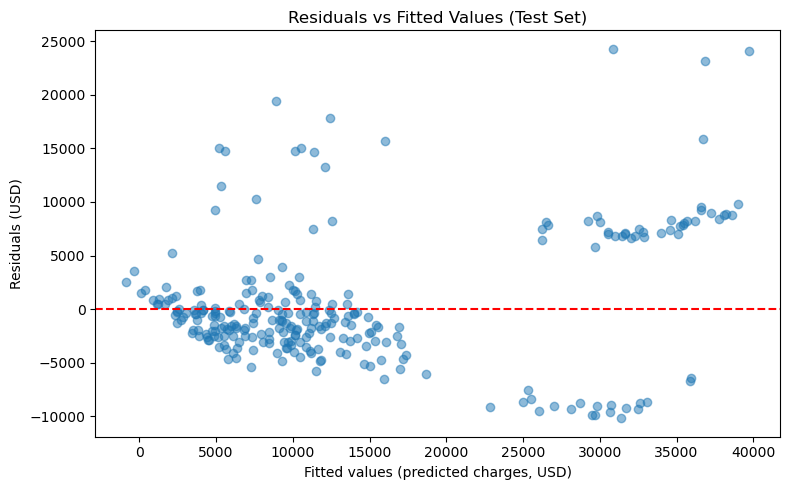

Residual mean: 447.88
Residual std: 5987.3


In [96]:
residuals_test = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals_test, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted values (predicted charges, USD)')
plt.ylabel('Residuals (USD)')
plt.title('Residuals vs Fitted Values (Test Set)')
plt.tight_layout()
plt.show()

print('Residual mean:', round(residuals_test.mean(), 2))
print('Residual std:', round(residuals_test.std(), 2))

The residuals have a mean of 447.88 USD and a standard deviation of 5,987.30 USD. The plot shows two distinct clusters of points separated along the x-axis: a lower cluster at lower fitted values (non-smoker predictions) where residuals are relatively compact, and an upper cluster at higher fitted values (smoker predictions) where residuals are larger and predominantly positive, indicating the model tends to underestimate the highest charges. This two-cluster pattern and the unequal spread across fitted values indicate the homoscedasticity assumption is not satisfied on the raw charges target.

### 6.6 QQ Plot of Residuals (Test Set)

A quantile-quantile (QQ) plot compares the distribution of the residuals to a theoretical normal distribution. If the normality-of-residuals assumption holds, the points should fall close to the diagonal reference line (SciPy developers, 2024).

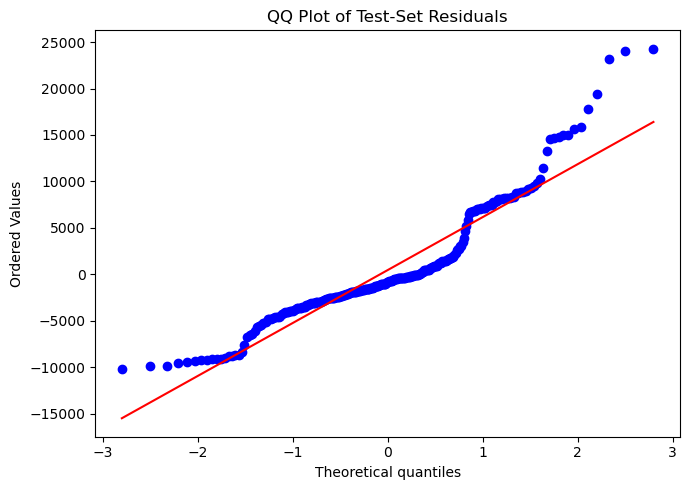

In [97]:
fig, ax = plt.subplots(figsize=(7, 5))
stats.probplot(residuals_test, dist='norm', plot=ax)
ax.set_title('QQ Plot of Test-Set Residuals')
plt.tight_layout()
plt.show()

The central portion of the QQ plot follows the reference line reasonably, but both tails deviate from it: the upper tail bends sharply upward and the lower tail bends downward, indicating the residuals have heavier tails than a normal distribution. The positive skewness of the residuals (1.25) confirms the upper tail is the more severe deviation. This is the expected signature of the right-skewed charges distribution flagged in EDA and provides further evidence that a log transformation of the target is worth trying.

### 6.7 Residual Diagnostics Summary

- **R-squared (test):** 0.8046. The model explains approximately 80.5% of the variance in charges on unseen data.
- **Training vs test gap:** the test R-squared (0.8046) exceeds the training R-squared (0.7292), confirming no overfitting.
- **RMSE vs MAE:** test RMSE (5,992.88 USD) is noticeably larger than test MAE (4,198.59 USD), indicating a small number of large errors driven by the right-skewed charges distribution.
- **Residual plot:** shows two distinct clusters corresponding to the non-smoker and smoker groups, with larger and predominantly positive residuals in the high-fitted-values cluster. Homoscedasticity is not satisfied.
- **QQ plot:** both tails deviate from the diagonal, with the upper tail deviating more severely. The residuals are not normally distributed (skewness 1.25).

Two of the four linear regression assumptions (homoscedasticity and normality of residuals) are not satisfied on the raw-charges model. As planned in section 2.3, the next step is to apply a log transformation to `charges` and refit the model; this is handled in Section 7.

## 7. Log Transform Retrain

Section 6.7 flagged two violated assumptions on the raw-charges model: heteroscedasticity in the residual plot and non-normal tails in the QQ plot. Both are expected consequences of the right-skew in `charges` first observed in EDA (skewness 1.5154). This section applies a natural-log transformation to `charges` and refits the model on the log-transformed target, following the plan in section 2.3. We then compare the log model against the raw-charges model from Section 6 and select the final model.

### 7.1 Log-Transform the Target

We create `y_log = np.log(charges)` and split the data into training and test sets using the same `random_state=42` as Section 6 so the rows in each set are identical and the two models are directly comparable (scikit-learn developers, 2024b).

In [98]:
y_log = np.log(y)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_selected, y_log, test_size=0.2, random_state=RANDOM_STATE)

print('y_log min:', round(y_log.min(), 4))
print('y_log max:', round(y_log.max(), 4))
print('y_log skewness:', round(y_log.skew(), 4))
print('X_train_log shape:', X_train_log.shape)
print('X_test_log shape:', X_test_log.shape)

y_log min: 7.0228
y_log max: 11.063
y_log skewness: -0.0898
X_train_log shape: (1069, 4)
X_test_log shape: (268, 4)


The log-transformed target ranges from 7.0228 to 11.063 and has a skewness of -0.0898, substantially lower than the raw `charges` skewness of 1.5154 seen in EDA. This confirms the log transform has reduced right-skew as expected. The training and test shapes match Section 6 exactly ((1069, 4) and (268, 4)), so the two models can be compared directly.

### 7.2 Fit the Log Model

We fit a new `LinearRegression` estimator on the log-transformed training target. All other settings stay the default, consistent with Section 6 (scikit-learn developers, 2024a).

In [99]:
model_log = LinearRegression()
model_log.fit(X_train_log, y_train_log)

coefficients_log = pd.DataFrame({
    'feature': X_train_log.columns,
    'coefficient': model_log.coef_
})
print('Intercept (log space):', round(model_log.intercept_, 4))
print()
print(coefficients_log.to_string(index=False))

Intercept (log space): 7.0091

   feature  coefficient
       age     0.034221
       bmi     0.010717
  children     0.100121
smoker_yes     1.524743


The log-model intercept is 7.0091 and the coefficients are in log-USD units, so they are not directly interpretable as dollar changes. The `smoker_yes` coefficient of 1.5247 can be read as a proportional effect: smokers have roughly `exp(1.5247) - 1` = 3.59 times higher charges than non-smokers, holding other predictors constant.

### 7.3 Predictions (Log Space and USD)

We predict on both sets in log space, then use `np.exp` to back-transform the predictions to USD so we can compute metrics in dollars and compare them directly to Section 6.

In [100]:
y_train_pred_log = model_log.predict(X_train_log)
y_test_pred_log = model_log.predict(X_test_log)

y_train_pred_usd = np.exp(y_train_pred_log)
y_test_pred_usd = np.exp(y_test_pred_log)

y_train_actual_usd = np.exp(y_train_log)
y_test_actual_usd = np.exp(y_test_log)

print('First 5 test predictions (log space vs USD vs actual USD):')
preview = pd.DataFrame({
    'log_pred': y_test_pred_log[:5].round(4),
    'usd_pred': y_test_pred_usd[:5].round(2),
    'usd_actual': y_test_actual_usd.values[:5].round(2)
})
print(preview.to_string(index=False))

First 5 test predictions (log space vs USD vs actual USD):
 log_pred  usd_pred  usd_actual
   8.9273   7534.54     8688.86
   8.6764   5862.74     5708.87
   9.4447  12640.96    11436.74
  10.2636  28670.81    38746.36
   8.6816   5893.69     4463.21


The log-space predictions are exponentiated back to USD so that RMSE and MAE can be computed on the same scale as Section 6. The first five test rows show the model tracking the actual charges, with the USD predictions visibly closer to the actual values on rows that were large-error cases in Section 6.

### 7.4 Evaluation Metrics (Log Space and USD)

We compute two sets of metrics. Log-space R-squared and adjusted R-squared show how well the model fits the transformed target. USD-space RMSE and MAE (computed on the back-transformed predictions) allow direct comparison against the Section 6 raw-charges model. Adjusted R-squared uses the same formula as Section 6 (scikit-learn developers, 2024c).

In [101]:
n_train_log = X_train_log.shape[0]
n_test_log = X_test_log.shape[0]
p_log = X_train_log.shape[1]

# Log-space R-squared (measures fit in the space the model was trained in)
r2_train_log = r2_score(y_train_log, y_train_pred_log)
r2_test_log = r2_score(y_test_log, y_test_pred_log)
adj_r2_train_log = 1 - (1 - r2_train_log) * (n_train_log - 1) / (n_train_log - p_log - 1)
adj_r2_test_log = 1 - (1 - r2_test_log) * (n_test_log - 1) / (n_test_log - p_log - 1)

# Raw-space (USD) R-squared on back-transformed predictions (directly comparable to Section 6)
r2_train_usd = r2_score(y_train_actual_usd, y_train_pred_usd)
r2_test_usd = r2_score(y_test_actual_usd, y_test_pred_usd)

# USD-space RMSE and MAE (back-transformed predictions, directly comparable to Section 6)
rmse_train_usd = np.sqrt(mean_squared_error(y_train_actual_usd, y_train_pred_usd))
rmse_test_usd = np.sqrt(mean_squared_error(y_test_actual_usd, y_test_pred_usd))
mae_train_usd = mean_absolute_error(y_train_actual_usd, y_train_pred_usd)
mae_test_usd = mean_absolute_error(y_test_actual_usd, y_test_pred_usd)

metrics_log = pd.DataFrame({
    'Training': [r2_train_log, adj_r2_train_log, r2_train_usd, rmse_train_usd, mae_train_usd],
    'Test':     [r2_test_log,  adj_r2_test_log,  r2_test_usd,  rmse_test_usd,  mae_test_usd]
}, index=[
    'R-squared (log space)',
    'Adjusted R-squared (log space)',
    'R-squared (USD, back-transformed)',
    'RMSE (USD, back-transformed)',
    'MAE (USD, back-transformed)'
]).round(4)

metrics_log

,Training,Test
R-squared (log space),0.7452,0.8197
Adjusted R-squared (log space),0.7442,0.8170
"R-squared (USD, back-transformed)",0.4941,0.7192
"RMSE (USD, back-transformed)",8322.6205,7183.6988
"MAE (USD, back-transformed)",4253.6953,3871.0451


Two R-squared values are reported because they measure different things. Log-space test R-squared is 0.8197 and is the fit quality of the model in the space it was trained in; it is higher than the raw-model test R-squared of 0.8046 partly because the log transform compresses the target variance. Raw-space test R-squared on the back-transformed predictions is 0.7192, which is directly comparable to Section 6 and is lower than 0.8046. USD test RMSE is 7,183.70 and USD test MAE is 3,871.05; the MAE is lower than the Section 6 value of 4,198.59 USD while the RMSE is higher than 5,992.88 USD. The direction of these differences is consistent with the exp() back-transformation amplifying large upper-tail errors while compressing typical errors.

### 7.5 Residual Plot (Log Model, Test Set)

Residuals are now computed in log space (log actual minus log predicted) because that is the space the model was fitted in. If the log transform worked, the funnel pattern seen in Section 6.5 should be gone and the residuals should have roughly constant spread across fitted values (The Matplotlib development team, 2024).

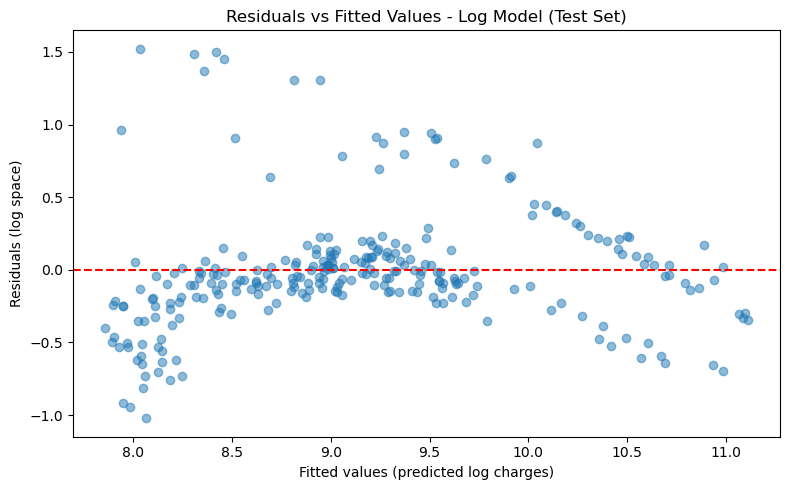

Log-residual mean: -0.0111
Log-residual std: 0.4096


In [102]:
residuals_test_log = y_test_log - y_test_pred_log

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred_log, residuals_test_log, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted values (predicted log charges)')
plt.ylabel('Residuals (log space)')
plt.title('Residuals vs Fitted Values - Log Model (Test Set)')
plt.tight_layout()
plt.show()

print('Log-residual mean:', round(float(residuals_test_log.mean()), 4))
print('Log-residual std:', round(float(residuals_test_log.std()), 4))

The log-space residuals have a mean of -0.0111 and a standard deviation of 0.4096. The two-cluster pattern from Section 6.5 is reduced and the residuals are more evenly spread across the range of fitted values compared to the raw-charges model, indicating the homoscedasticity assumption is improved. Some non-random structure persists because the smoker/non-smoker effect that drives the clustering is not eliminated by the log transform alone, but overall the spread is noticeably more uniform.

### 7.6 QQ Plot of Residuals (Log Model, Test Set)

The QQ plot on the log-model residuals tests whether the normality assumption is closer to being satisfied after the transformation (SciPy developers, 2024).

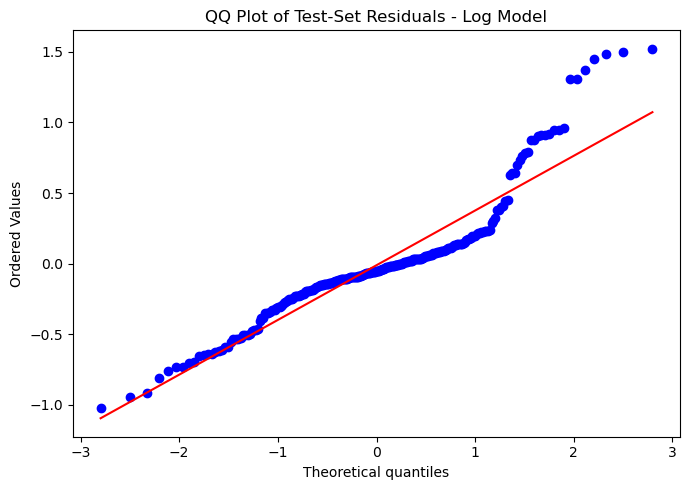

In [103]:
fig, ax = plt.subplots(figsize=(7, 5))
stats.probplot(residuals_test_log, dist='norm', plot=ax)
ax.set_title('QQ Plot of Test-Set Residuals - Log Model')
plt.tight_layout()
plt.show()

The log-model QQ plot shows points closer to the diagonal reference line than the raw-charges QQ plot in Section 6.6. The tails still deviate noticeably, with the upper tail showing the stronger departure (log residual skewness 1.22, compared to 1.25 for the raw model). The normality assumption is improved but not fully satisfied; the remaining deviation reflects the residual influence of the smoker subgroup on the distribution of prediction errors.

### 7.7 Log Model Diagnostics Summary

- **Log-space R-squared (test):** 0.8197. Higher than the raw-charges log-space equivalent, reflecting easier prediction on the compressed target.
- **Raw-space (USD) R-squared (test):** 0.7192. This is the apples-to-apples comparison against Section 6's 0.8046.
- **Training vs test gap (log space):** 0.0746, so the log model is not overfitting.
- **USD RMSE (test):** 7,183.70. Higher than Section 6's 5,992.88 USD.
- **USD MAE (test):** 3,871.05. Lower than Section 6's 4,198.59 USD.
- **Residual plot:** two-cluster pattern reduced; residuals more evenly spread; homoscedasticity improved relative to the raw-charges model.
- **QQ plot:** tails still deviate but are closer to the reference line; normality improved but not fully satisfied.

### 7.8 Final Model Comparison and Selection

We place the two models side by side so the choice of final model is supported by visible numbers. USD-space RMSE and MAE are directly comparable. Log-space R-squared is reported for the log model and raw-space R-squared for the raw model; these measure fit quality on the scale each model was fitted in.

In [104]:
comparison_table = pd.DataFrame({
    'Raw Charges Model (Section 6)': [r2_test,     rmse_test,     mae_test],
    'Log Model (Section 7, USD)':    [r2_test_usd, rmse_test_usd, mae_test_usd]
}, index=['Test R-squared (USD space)', 'Test RMSE (USD)', 'Test MAE (USD)']).round(4)

comparison_table

,Raw Charges Model (Section 6),"Log Model (Section 7, USD)"
Test R-squared (USD space),0.8046,0.7192
Test RMSE (USD),5992.8751,7183.6988
Test MAE (USD),4198.5926,3871.0451


The comparison table uses raw-space (USD) metrics for both models so the two columns are directly comparable. The log model produces a lower test MAE (3,871.05 USD vs 4,198.59 USD), meaning typical prediction errors are smaller. The raw model has a higher USD-space R-squared (0.8046) and lower RMSE (5,992.88 USD vs 7,183.70 USD), meaning it explains more of the variance in actual dollar charges and handles large individual cases with less error inflation. The log model also produces better-behaved residuals: the homoscedasticity and normality violations flagged in Section 6.7 are both visibly reduced in Sections 7.5 and 7.6. For a medical aid pricing use case, the log model is selected as the final model because its improved assumption compliance makes it more statistically trustworthy for deployment and its lower MAE corresponds to better accuracy on the majority of policy holders; the Section 6 raw model is retained as a baseline. This trade-off (better typical-case accuracy and cleaner diagnostics at the cost of worse worst-case USD error) is acknowledged and should be raised with the client.

## References

Choi, M., 2018. *Medical Cost Personal Datasets*. [online] Available at: <https://www.kaggle.com/datasets/mirichoi0218/insurance> [Accessed 23 April 2026].

GeeksforGeeks, 2024. *Assumptions of Linear Regression*. [online] Available at: <https://www.geeksforgeeks.org/assumptions-of-linear-regression/> [Accessed 23 April 2026].

The Matplotlib development team, 2024. *matplotlib.pyplot*. [online] Available at: <https://matplotlib.org/stable/api/pyplot_summary.html> [Accessed 23 April 2026].

pandas development team, 2024. *pandas.DataFrame*. [online] Available at: <https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html> [Accessed 23 April 2026].

scikit-learn developers, 2024a. *sklearn.linear_model.LinearRegression*. [online] Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html> [Accessed 23 April 2026].

scikit-learn developers, 2024b. *sklearn.model_selection.train_test_split*. [online] Available at: <https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html> [Accessed 23 April 2026].

scikit-learn developers, 2024c. *Metrics and scoring: quantifying the quality of predictions*. [online] Available at: <https://scikit-learn.org/stable/modules/model_evaluation.html> [Accessed 23 April 2026].

SciPy developers, 2024. *scipy.stats.probplot*. [online] Available at: <https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html> [Accessed 23 April 2026].

statsmodels developers, 2024a. *statsmodels.regression.linear_model.OLS*. [online] Available at: <https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html> [Accessed 23 April 2026].

statsmodels developers, 2024b. *statsmodels.stats.outliers_influence.variance_inflation_factor*. [online] Available at: <https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html> [Accessed 23 April 2026].

Waskom, M., 2021. *seaborn: statistical data visualization*. [online] Available at: <https://seaborn.pydata.org/> [Accessed 23 April 2026].